## QML-FAST: Packed storage and new features

Same 3-field setup as `example.ipynb`, but demonstrating the new functionality:

1. **`getF_packed`** — packed storage (no zero-padding), ~2x faster, ~4x less memory
2. **`getF_batched`** — memory-budgeted batching for large Nf
3. **`profile_access`** — VCinvV access profiling
4. **`pack_basis`** — arbitrary rank-one decompositions (not just spherical harmonics)

In [1]:
import sys
sys.path.append('./')
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import opt_einsum as oe
from tqdm import tqdm
import time

### 1. Simulation setup (same as example.ipynb)

In [2]:
nside = 16
lmax  = 3*nside - 1
ell   = np.arange(lmax+1).astype(float)

S_aa = (ell+1)**(-2)
S_bb = 3*(ell+1)**(-2)
S_cc = 5*(ell+1)**(-2)
S_ab = np.sqrt(S_aa*S_bb)
S_ca = np.sqrt(S_aa*S_cc)
S_bc = np.sqrt(S_bb*S_cc)

N_a = 5e-2
N_b = 5e-2
N_c = 1e-2

A_ab = 0.3
A_ca = 0.5
A_bc = 0.5

C_aa = S_aa + N_a
C_bb = S_bb + N_b
C_cc = S_cc + N_c
C_ab = A_ab*S_ab
C_ca = A_ca*S_ca
C_bc = A_bc*S_bc

Sky fraction: 0.65


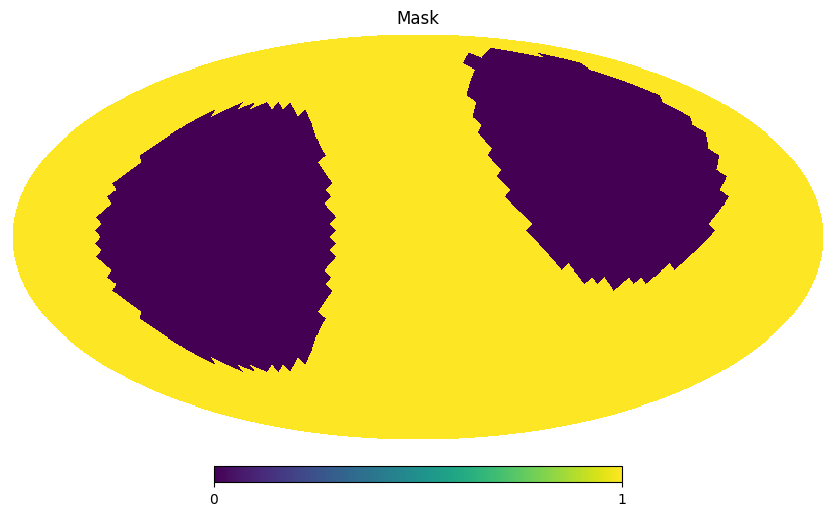

In [3]:
# Mask
vec = hp.ang2vec(np.pi / 2, np.pi/2)
ipix_disc = hp.query_disc(nside=nside, vec=vec, radius=np.radians(51))
vec1 = hp.ang2vec(np.pi / 3, 3*np.pi/2)
ipix_disc1 = hp.query_disc(nside=nside, vec=vec1, radius=np.radians(47))

m = np.ones(hp.nside2npix(nside))
m[ipix_disc] = 0.
m[ipix_disc1] = 0.
hp.mollview(m, title='Mask')
print(f'Sky fraction: {m.mean():.2f}')

In [ ]:
from utilities import *
from qmlfast import *

def get_pix_cov_block(cl, Pl_ij, lmin, lmax):
    return oe.contract('ijk,i->jk', Pl_ij[lmin:lmax], cl[lmin:lmax])

theta, phi = theta_phi(nside)
theta = theta[m==1]
phi = phi[m==1]
Pl_ij = get_Pl_ij(theta, phi, nside, lmax=3*nside-1)

cov_a  = get_pix_cov_block(S_aa, Pl_ij, 0, 3*nside)  # FIX: was 3*nside-1
cov_b  = get_pix_cov_block(S_bb, Pl_ij, 0, 3*nside)  # FIX: was 3*nside-1
cov_c  = get_pix_cov_block(S_cc, Pl_ij, 0, 3*nside)  # FIX: was 3*nside-1
cov_ab = get_pix_cov_block(S_ab, Pl_ij, 0, 3*nside)  # FIX: was 3*nside-1
cov_bc = get_pix_cov_block(S_bc, Pl_ij, 0, 3*nside)  # FIX: was 3*nside-1
cov_ca = get_pix_cov_block(S_ca, Pl_ij, 0, 3*nside)  # FIX: was 3*nside-1

Np = cov_a.shape[0]
omega_pix = 4 * np.pi / hp.nside2npix(nside)

large_cov = np.zeros([3*Np, 3*Np])
large_cov[block_np(0, 0, Np)] = cov_a + np.eye(Np)*N_a/omega_pix
large_cov[block_np(0, 1, Np)] = cov_ab
large_cov[block_np(0, 2, Np)] = cov_ca
large_cov[block_np(1, 0, Np)] = cov_ab.T
large_cov[block_np(1, 1, Np)] = cov_b + np.eye(Np)*N_b/omega_pix
large_cov[block_np(1, 2, Np)] = cov_bc
large_cov[block_np(2, 0, Np)] = cov_ca.T
large_cov[block_np(2, 1, Np)] = cov_bc.T
large_cov[block_np(2, 2, Np)] = cov_c + np.eye(Np)*N_c/omega_pix

### 2. Mode deprojection (same as example.ipynb)

In [5]:
import scipy as sp

ell0 = 4
Z, pi = construct_Z_and_pi(theta, phi, ell0=ell0, lmax=3*nside-1)

for i in range(3):
    for j in range(3):
        block = large_cov[block_np(i,j,Np)]
        large_cov[block_np(i,j,Np)] = pi@block@pi.T

eta = 1e-1
M = np.linalg.inv(large_cov + eta*sp.linalg.block_diag(Z@Z.T, Z@Z.T, Z@Z.T))
for i in range(3):
    for j in range(3):
        block = M[block_np(i,j,Np)]
        M[block_np(i,j,Np)] = pi@block@pi.T

### 3. Fisher matrix: original vs packed

We compute the Fisher matrix with both methods and compare speed and memory.

In [6]:
Nf = 3
F_idx = np.array([(i, j, l) for l in range(0, 3*nside)
                  for i in range(Nf) for j in range(i, Nf)])
C_map = np.ones([3, 3])

Y_r_all = sph_harm_y_real_all(3*nside, theta, phi)
print(f'Y_r_all (padded): {Y_r_all.shape} = {Y_r_all.nbytes/1e6:.1f} MB')

Y_r_all (padded): (48, 95, 2008) = 73.3 MB


In [7]:
# Original method (padded, opt_einsum)
t0 = time.perf_counter()
F_original = getF(Y_r_all, M, F_idx, Nf, Np, C_map)
t_original = time.perf_counter() - t0
print(f'Original getF: {t_original:.2f} s')

YCinvY: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:07<00:00,  1.25s/it]


Original getF: 10.19 s


In [8]:
# Packed method (no padding, BLAS matmuls)
V_packed, offsets, ranks = pack_sph_harm(Y_r_all)
print(f'V_packed:       {V_packed.shape} = {V_packed.nbytes/1e6:.1f} MB')
print(f'Memory savings: {Y_r_all.nbytes / V_packed.nbytes:.1f}x\n')

t0 = time.perf_counter()
F_packed = getF_packed(V_packed, offsets, ranks, M, F_idx, Nf, Np, C_map)
t_packed = time.perf_counter() - t0
print(f'Packed getF:    {t_packed:.2f} s')
print(f'Speedup:        {t_original/t_packed:.1f}x')

V_packed:       (2304, 2008) = 37.0 MB
Memory savings: 2.0x



VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.16it/s]


Packed getF:    4.53 s
Speedup:        2.2x


In [9]:
# Verify consistency
diff = np.max(np.abs(F_original - F_packed))
rel = diff / np.max(np.abs(F_original))
print(f'max|F_original - F_packed| = {diff:.2e}')
print(f'relative error = {rel:.2e}')

max|F_original - F_packed| = 1.46e-11
relative error = 7.07e-17


### 4. VCinvV access profiling

Before deciding on a memory budget for `getF_batched`, we can profile how often each field pair is accessed.

In [10]:
counts = profile_access(F_idx, Nf, C_map)
total = counts.sum()

print('VCinvV access counts per field pair:')
for i in range(Nf):
    for j in range(i+1):
        pct = 100.0 * counts[i,j] / total
        print(f'  ({i},{j}): {counts[i,j]:>8d}  ({pct:5.1f}%)')
print(f'  total: {total}')
print(f'\nOff-diagonal pairs are accessed 2x more (combinatorial symmetry).')

VCinvV access counts per field pair:
  (0,0):    20880  ( 11.1%)
  (1,0):    41568  ( 22.2%)
  (1,1):    20880  ( 11.1%)
  (2,0):    41568  ( 22.2%)
  (2,1):    41568  ( 22.2%)
  (2,2):    20880  ( 11.1%)
  total: 187344

Off-diagonal pairs are accessed 2x more (combinatorial symmetry).


### 5. Batched computation (memory-budgeted)

For large Nf (e.g. 40 fields, 820 field pairs), precomputing all VCinvV matrices may exceed memory.
`getF_batched` trades time for memory by processing field pairs in batches.

In [11]:
# With Nf=3, there are only 6 active field pairs.
# budget=6 -> all at once (same as getF_packed)
# budget=2 -> 3 batches, 6 batch-pair iterations
# budget=1 -> 6 batches, 21 batch-pair iterations (extreme)

for budget in [6, 3, 2, 1]:
    t0 = time.perf_counter()
    F_b = getF_batched(V_packed, offsets, ranks, M, F_idx, Nf, Np, C_map, budget=budget)
    dt = time.perf_counter() - t0
    err = np.max(np.abs(F_b - F_packed)) / np.max(np.abs(F_packed))
    print(f'budget={budget}: {dt:.2f}s, rel_err={err:.1e}')

VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:25<00:00,  4.24s/it]


budget=6: 25.54s, rel_err=0.0e+00


batched F: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:19<00:00,  6.37s/it]


budget=3: 19.14s, rel_err=7.1e-17


batched F: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:25<00:00,  4.30s/it]


budget=2: 25.78s, rel_err=7.1e-17


batched F: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:17<00:00,  1.22it/s]

budget=1: 17.26s, rel_err=7.1e-17


### 6. Sanity check: $\ell < \ell_{\min}$ block is zero

In [12]:
F = F_packed  # use the packed result from here on
null_block = F[np.ix_(F_idx[:,2]<ell0, F_idx[:,2]<ell0)]
print(f'F[ell<ell0, ell<ell0] max = {np.max(np.abs(null_block)):.1e}  (should be ~0)')

F[ell<ell0, ell<ell0] max = 1.1e-29  (should be ~0)


### 7. Run simulations and compute QML estimates

In [ ]:
ys = []
for i in tqdm(range(2500)):
    alm_a, alm_b, alm_c = hp.synalm([C_aa, C_ab, C_ca, C_bb, C_bc, C_cc], lmax=lmax)
    x = np.stack([hp.alm2map(alm_a, nside)[m==1],
                  hp.alm2map(alm_b, nside)[m==1],
                  hp.alm2map(alm_c, nside)[m==1]])
    y = get_y(x, Y_r_all, M, F_idx, Nf, Np)
    ys.append(y)

In [ ]:
# Remove the null block and invert
ys = np.array(ys)[:, F_idx[:,2]>=ell0]
F = F[np.ix_(F_idx[:,2]>=ell0, F_idx[:,2]>=ell0)]
invF = np.linalg.inv(F)
es = ys @ invF
e_mean = es.mean(axis=0)
err_analytic = invF
err_empirical = np.cov(es, rowvar=False, ddof=0)
f_idx = F_idx[F_idx[:,2]>=ell0]

### 8. Plot auto-power spectra

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

spectra = [
    ((0,0), C_aa, r'$C_{aa}$'),
    ((1,1), C_bb, r'$C_{bb}$'),
    ((2,2), C_cc, r'$C_{cc}$'),
]

for col, ((fi, fj), C_true, label) in enumerate(spectra):
    idx = (f_idx[:,0]==fi) * (f_idx[:,1]==fj)
    ells_plot = np.arange(ell0, 3*nside)

    axs[0, col].errorbar(ells_plot, e_mean[idx],
                         yerr=np.sqrt(err_analytic[idx, idx]), lw=1, label='QML')
    axs[0, col].semilogy(np.arange(len(C_true)), C_true, '.', label='True')
    axs[0, col].set_xlabel(r'$\ell$', fontsize=14)
    axs[0, col].set_ylabel(label, fontsize=14)
    axs[0, col].legend(fontsize=12)
    axs[0, col].grid(alpha=0.5)

    axs[1, col].semilogy(ells_plot, np.sqrt(err_analytic[idx, idx]), lw=1, label='Analytic')
    axs[1, col].semilogy(ells_plot, np.sqrt(err_empirical[idx, idx]), lw=1, label='Empirical')
    axs[1, col].set_xlabel(r'$\ell$', fontsize=14)
    axs[1, col].set_ylabel(f'$\\sigma$({label})', fontsize=14)
    axs[1, col].legend(fontsize=12)
    axs[1, col].grid(alpha=0.5)

plt.tight_layout()
plt.show()

### 9. Plot cross-power spectra

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

cross = [
    ((0,1), C_ab, r'$C_{ab}$'),
    ((0,2), C_ca, r'$C_{ac}$'),
    ((1,2), C_bc, r'$C_{bc}$'),
]

for col, ((fi, fj), C_true, label) in enumerate(cross):
    idx = (f_idx[:,0]==fi) * (f_idx[:,1]==fj)
    ells_plot = np.arange(ell0, 3*nside)

    axs[0, col].errorbar(ells_plot, e_mean[idx],
                         yerr=np.sqrt(err_analytic[idx, idx]), lw=1, label='QML')
    axs[0, col].plot(np.arange(len(C_true)), C_true, '.', label='True')
    axs[0, col].set_xlabel(r'$\ell$', fontsize=14)
    axs[0, col].set_ylabel(label, fontsize=14)
    axs[0, col].legend(fontsize=12)
    axs[0, col].grid(alpha=0.5)

    axs[1, col].semilogy(ells_plot, np.sqrt(err_analytic[idx, idx]), lw=1, label='Analytic')
    axs[1, col].semilogy(ells_plot, np.sqrt(err_empirical[idx, idx]), lw=1, label='Empirical')
    axs[1, col].set_xlabel(r'$\ell$', fontsize=14)
    axs[1, col].set_ylabel(f'$\\sigma$({label})', fontsize=14)
    axs[1, col].legend(fontsize=12)
    axs[1, col].grid(alpha=0.5)

plt.tight_layout()
plt.show()

### Summary

| Method | What it does | When to use |
|--------|-------------|-------------|
| `getF(Y_r_all, ...)` | Original padded 4D storage with opt_einsum | Backward compatibility |
| `getF_packed(V_packed, offsets, ranks, ...)` | Packed 2D storage, BLAS matmuls | Default — faster and less memory |
| `getF_batched(..., budget=N)` | Batched packed computation | Large Nf where all VCinvV don't fit in RAM |
| `pack_sph_harm(Y_r_all)` | Convert spherical harmonics to packed format | Use with `getF_packed` |
| `pack_basis(V_list)` | Convert arbitrary rank-one vectors to packed format | Band-power Fisher, custom decompositions |
| `profile_access(F_idx, Nf, C_map)` | Count VCinvV lookups per field pair | Choosing `budget` for `getF_batched` |